In [7]:
import matplotlib.pyplot as plt
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from tqdm import trange

from gulps import logger
from gulps.core.coverage import coverage_report
from gulps.core.invariants import GateInvariants
from gulps.core.isa import DiscreteISA
from gulps.gulps_decomposer import GulpsDecomposer
from gulps.viz.invariant_viz import plot_decomposition
from qiskit import QuantumCircuit
from gulps.viz.report_viz import report_benchmark_results
from gulps.isa_library.fsim import fsim
import numpy as np

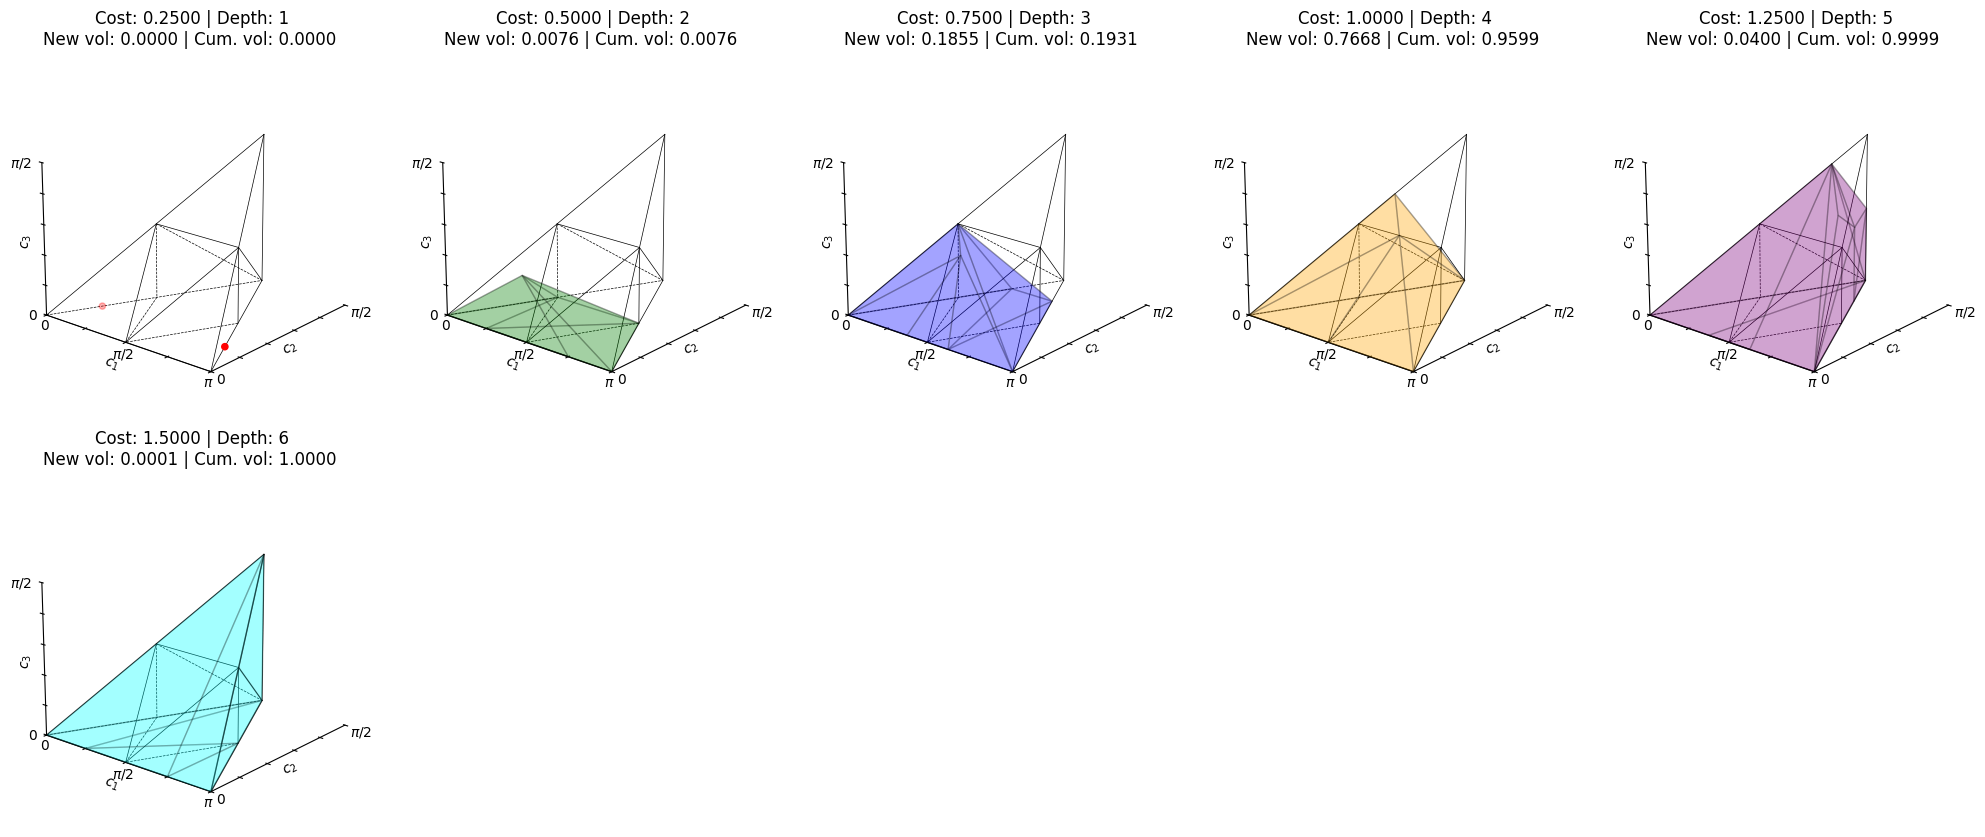

Coverage Set Statistics (Haar-averaged over SU(4))
Expected Cost:  0.959894
  → Average cost per random 2-qubit unitary

Expected Depth: 3.839575
  → Average number of 2-qubit gates


In [8]:
# comment out what you don't want or add your own
isa = [
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (CXGate().power(1 / 3), 1 / 3, "sqrt3cx"),
    # (CXGate().power(1 / 6), 1 / 6, "sqrt6cx"),
    # (iSwapGate(), 1.0, "iswap"),
    # (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    # (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (iSwapGate().power(1 / 6), 1 / 6, "sqrt6iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 4), 1 / 4, "sqrt4fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 6), 1 / 6, "sqrt6fsim"),
    # (SwapGate(), 0.0, "swap"),
    # (SwapGate().power(1 / 2), 1 / 2, "eswap"),
    # (SwapGate().power(1 / 3), 1 / 3, "eswap"),
]
gate_set, costs, names = zip(*isa)
isa = DiscreteISA(gate_set, costs, names, precompute_polytopes=True)
decomposer = GulpsDecomposer(isa=isa)

if hasattr(decomposer.isa, "coverage_set"):
    report = coverage_report(decomposer.isa.coverage_set)

In [9]:
# Warm-start to trigger JIT compilation (optional)
_ = decomposer(random_unitary(4, seed=9999))

In [10]:
logger.setLevel("INFO")
N = 1_000

fidelities = []
all_timings = []
failures = 0

for idx in trange(N, desc="Decomposing random unitaries"):
    u = random_unitary(4, seed=idx)
    try:
        fid = average_gate_fidelity(u, Operator(decomposer(u)))
        if fid < 1 - 1e-8:
            raise ValueError(f"Fidelity too low: {fid:.8f}")

        fidelities.append(fid)
        all_timings.append(decomposer.last_timing)

    except Exception as e:
        print(f"[WARN] Failed on unitary {idx}: {e}")
        failures += 1

Decomposing random unitaries: 100%|██████████| 1000/1000 [00:07<00:00, 125.96it/s]


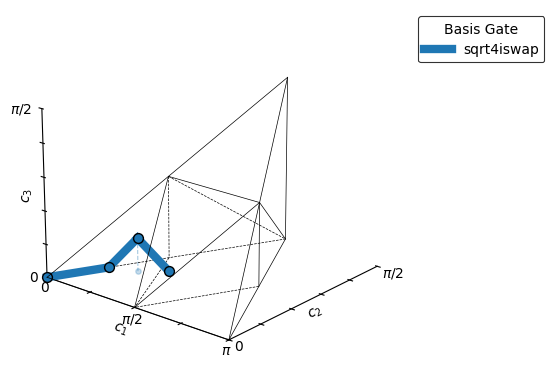

In [11]:
from IPython.display import display, clear_output
import time

fig_display = display(display_id=True)

for _i in range(20):
    clear_output(wait=True)
    r = decomposer._best_decomposition(GateInvariants.from_unitary(random_unitary(4)))
    fig = plot_decomposition(r.intermediates, r.sentence, isa)

    display(fig)
    plt.close(fig)
    time.sleep(0.15)  # 150ms delay

Benchmark: 1000/1000 successful (0 failures)
Fidelity: median=1.0000000000, min=1.0000000000
Avg time: 6.5 ms/decomposition
Cache: 20.0% hit rate (570/2852)


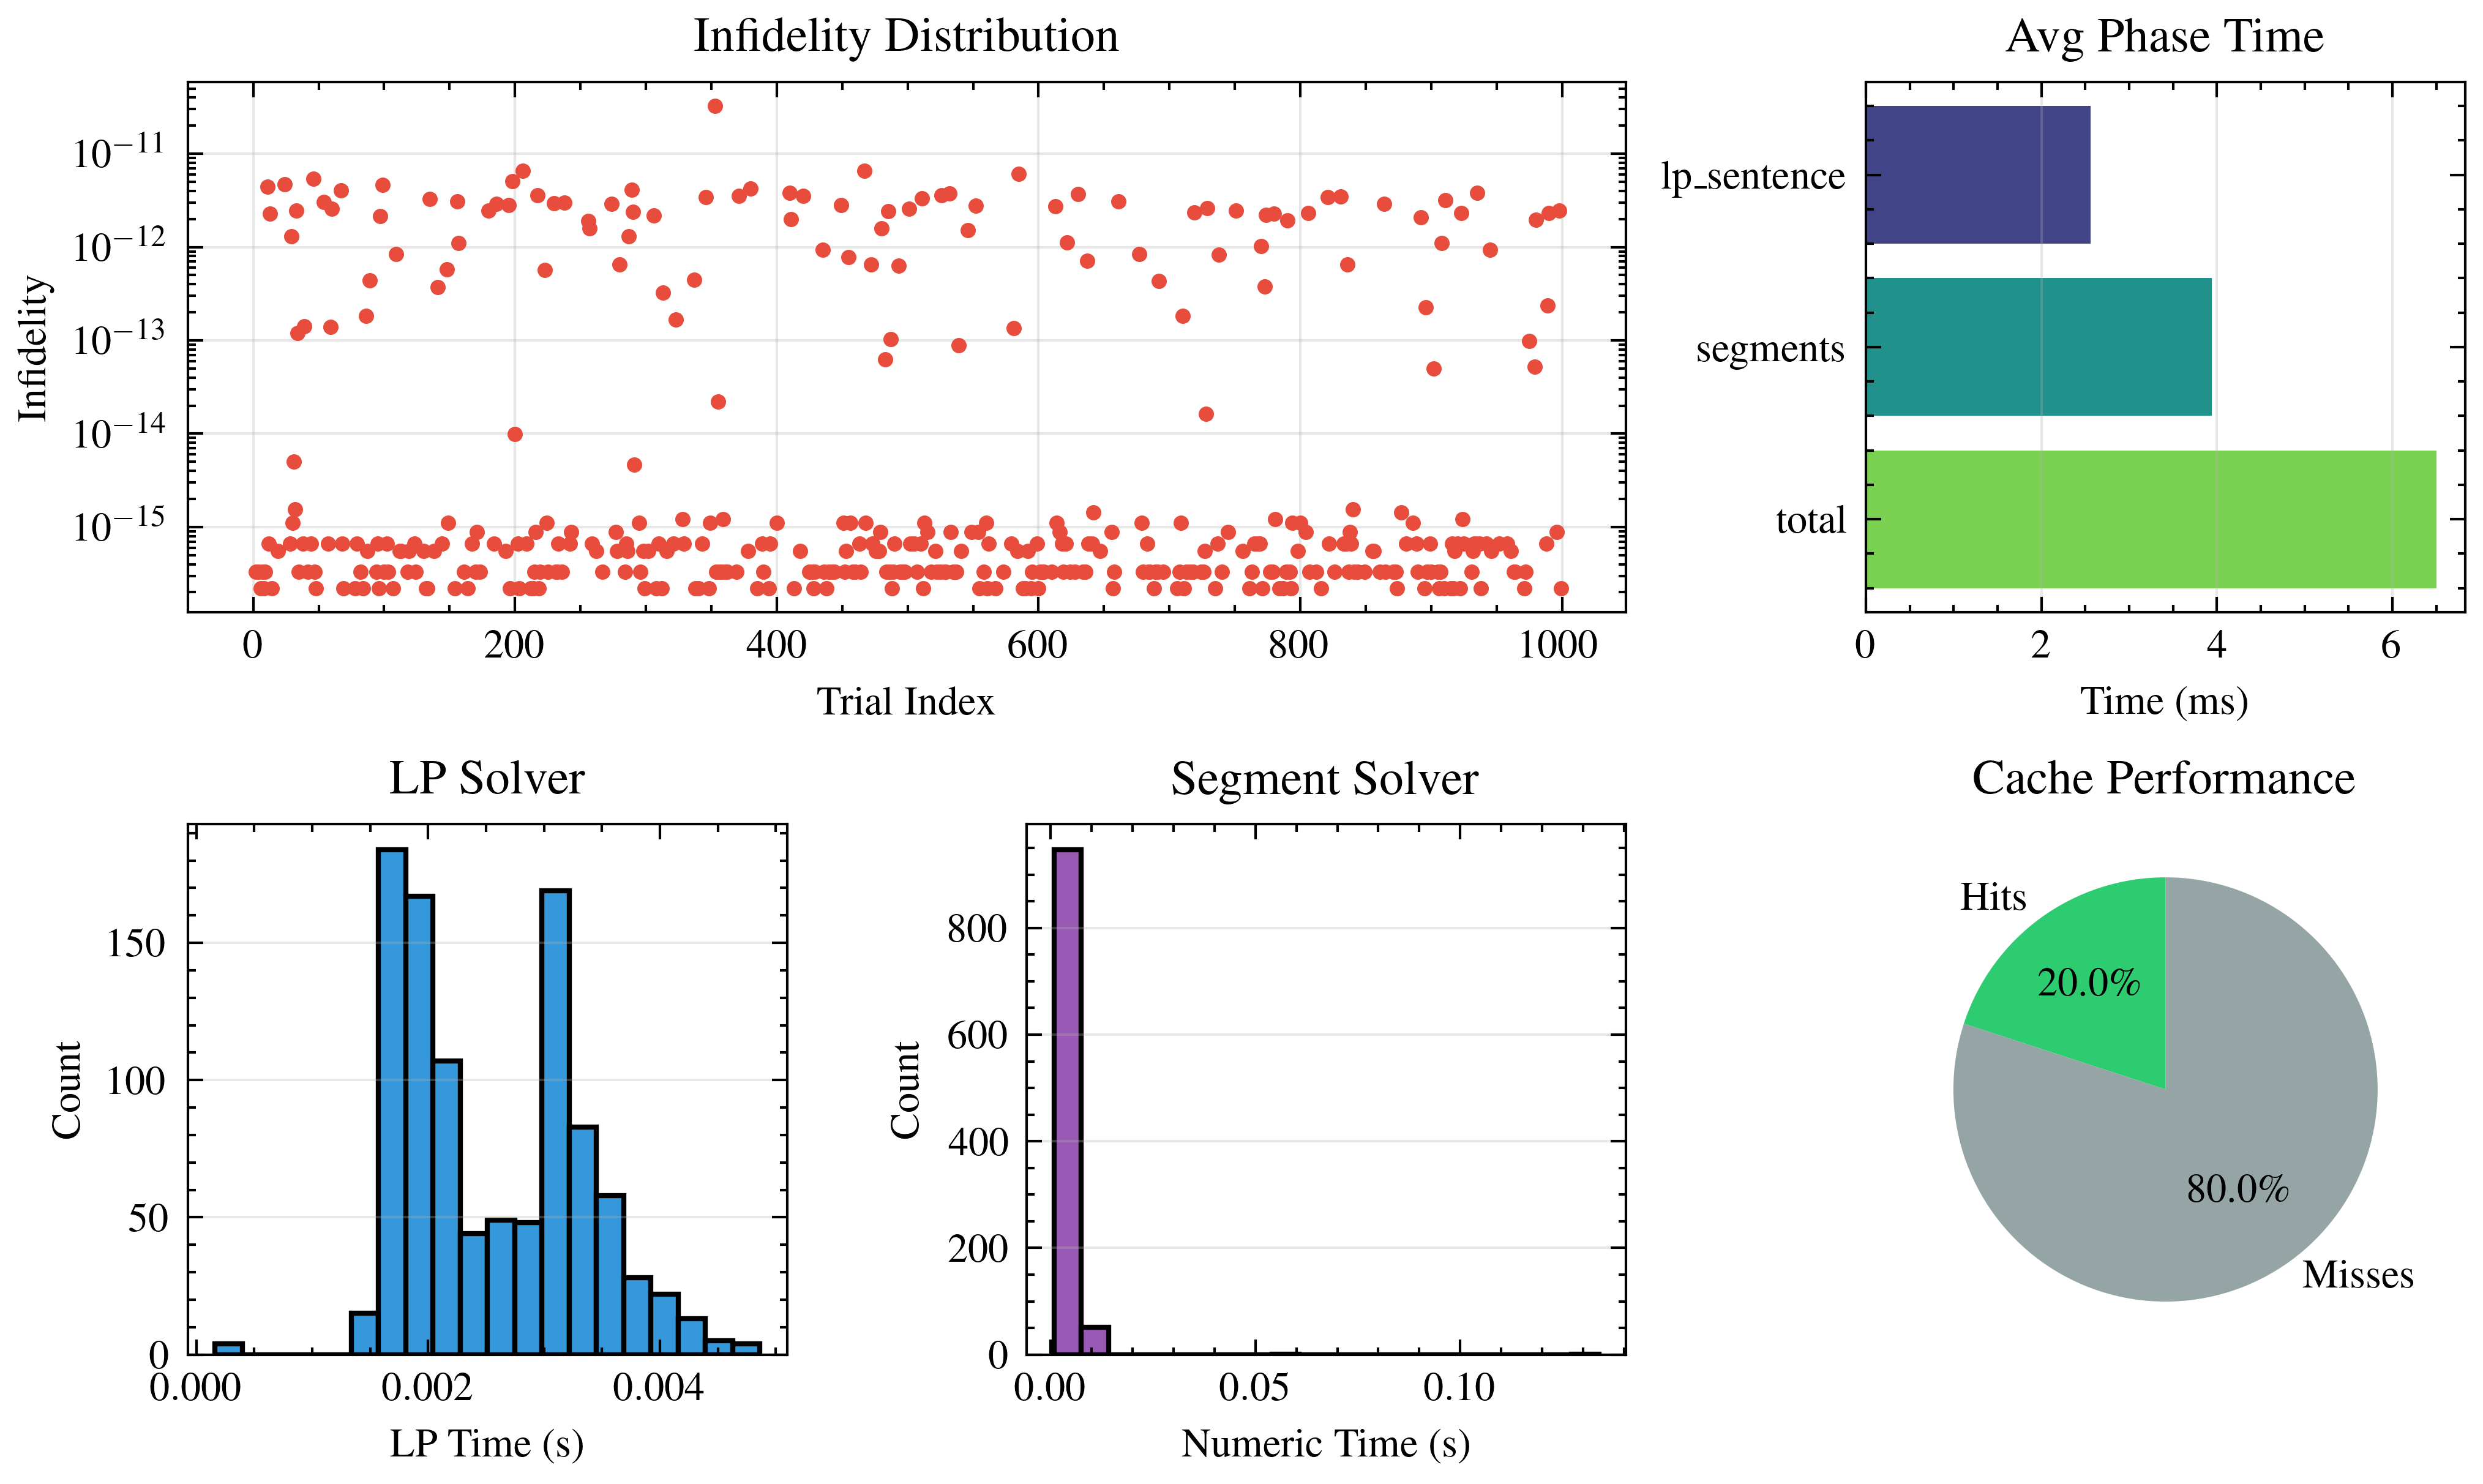

In [12]:
report_benchmark_results(fidelities, all_timings, decomposer, N, failures)